# 🌦️ Exploratory Data Analysis (EDA) — Weather Dataset
**Dataset:** `WeatherData.csv` — Hourly weather observations (Canada, 2012)  
**Goal:** Explore weather patterns, answer analytical questions, and uncover insights from real-world time-series weather data  
**Tools:** Pandas · Matplotlib · Seaborn


## 1. Imports

In [55]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [56]:
# Load the weather dataset and parse the Date/Time column as a proper datetime object
# parse_dates allows us to use time-based filtering and analysis later
data = pd.read_csv('WeatherData.csv', parse_dates=['Date/Time'])

## 3. First Look at the Data

In [57]:
# Display the first 5 rows to understand the structure
data.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [58]:
# Display the last 5 rows to confirm full loading
data.tail()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
8779,2012-12-31 19:00:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,2012-12-31 20:00:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,2012-12-31 21:00:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,2012-12-31 22:00:00,-0.2,-1.8,89,28,9.7,99.91,Snow
8783,2012-12-31 23:00:00,0.0,-2.1,86,30,11.3,99.89,Snow


## 4. Data Structure & Info

In [59]:
# Number of rows and columns
print("Shape:", data.shape)

Shape: (8784, 8)


In [60]:
# Index range
print("Index:", data.index)

Index: RangeIndex(start=0, stop=8784, step=1)


In [61]:
# All column names
print("Columns:", data.columns.tolist())

Columns: ['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather']


In [62]:
# Data type for each column
data.dtypes

Date/Time           datetime64[us]
Temp_C                     float64
Dew Point Temp_C           float64
Rel Hum_%                    int64
Wind Speed_km/h              int64
Visibility_km              float64
Press_kPa                  float64
Weather                        str
dtype: object

In [63]:
# Full info including non-null counts and memory usage
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date/Time         8784 non-null   datetime64[us]
 1   Temp_C            8784 non-null   float64       
 2   Dew Point Temp_C  8784 non-null   float64       
 3   Rel Hum_%         8784 non-null   int64         
 4   Wind Speed_km/h   8784 non-null   int64         
 5   Visibility_km     8784 non-null   float64       
 6   Press_kPa         8784 non-null   float64       
 7   Weather           8784 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(2), str(1)
memory usage: 549.1 KB


## 5. Data Quality Check

In [64]:
# Check for missing values in each column
data.isnull().sum()

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

In [65]:
# Check for duplicate rows
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


## 6. Descriptive Statistics

In [66]:
# Statistical summary of all numerical columns (mean, std, min, max, quartiles)
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Date/Time,8784,2012-07-01 23:30:00,2012-01-01 00:00:00,2012-04-01 11:45:00,2012-07-01 23:30:00,2012-10-01 11:15:00,2012-12-31 23:00:00,NaN
Temp_C,8784.0,8.798144,-23.3,0.1,9.3,18.8,33.0,11.687883
Dew Point Temp_C,8784.0,2.555294,-28.5,-5.9,3.3,11.8,24.4,10.883072
Rel Hum_%,8784.0,67.431694,18.0,56.0,68.0,81.0,100.0,16.918881
Wind Speed_km/h,8784.0,14.945469,0.0,9.0,13.0,20.0,83.0,8.688696
Visibility_km,8784.0,27.664447,0.2,24.1,25.0,25.0,48.3,12.622688
Press_kPa,8784.0,101.051623,97.52,100.56,101.07,101.59,103.65,0.844005


In [67]:
# Count of unique values per column — helps understand cardinality
data.nunique()

Date/Time           8784
Temp_C               533
Dew Point Temp_C     489
Rel Hum_%             83
Wind Speed_km/h       34
Visibility_km         24
Press_kPa            518
Weather               50
dtype: int64

In [68]:
# Non-null count per column
data.count()

Date/Time           8784
Temp_C              8784
Dew Point Temp_C    8784
Rel Hum_%           8784
Wind Speed_km/h     8784
Visibility_km       8784
Press_kPa           8784
Weather             8784
dtype: int64

## 7. Column Renaming

> ⚠️ **Challenge:** The `Weather` column name is too generic and clashes with the dataset name itself.  
> Renaming it to `Weather_Condition` makes the code cleaner and avoids ambiguity — especially important when writing complex filters with multiple conditions.


In [69]:
# Rename 'Weather' to 'Weather_Condition' for clarity in all subsequent code
data.rename(columns={'Weather': 'Weather_Condition'}, inplace=True)

# Confirm the rename
print(data.columns.tolist())

['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather_Condition']


## 8. Categorical Exploration

In [70]:
# All unique weather condition types in the dataset
data['Weather_Condition'].unique()

<StringArray>
[                                    'Fog',
                    'Freezing Drizzle,Fog',
                           'Mostly Cloudy',
                                  'Cloudy',
                                    'Rain',
                            'Rain Showers',
                            'Mainly Clear',
                            'Snow Showers',
                                    'Snow',
                                   'Clear',
                       'Freezing Rain,Fog',
                           'Freezing Rain',
                        'Freezing Drizzle',
                               'Rain,Snow',
                           'Moderate Snow',
                   'Freezing Drizzle,Snow',
               'Freezing Rain,Snow Grains',
                       'Snow,Blowing Snow',
                            'Freezing Fog',
                                    'Haze',
                                'Rain,Fog',
                             'Drizzle,Fog',
                  

In [71]:
# How often each weather condition occurs — sorted by frequency
data['Weather_Condition'].value_counts()

Weather_Condition
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Haze                                         16
Thunderstorms,Rain Showers                   16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle      

---
## 📋 Analytical Questions
---

### Q1 — All unique Wind Speed values

In [72]:
# Find all distinct wind speed values recorded in the dataset
data['Wind Speed_km/h'].unique()

array([ 4,  7,  6,  9, 15, 13, 20, 22, 19, 24, 30, 35, 39, 32, 33, 26, 44,
       43, 48, 37, 28, 17, 11,  0, 83, 70, 57, 46, 41, 52, 50, 63, 54,  2])

### Q2 — How many times was the weather exactly 'Clear'?

In [73]:
# Count rows where weather condition is exactly 'Clear'
# Using both approaches for comparison
clear_filter = data[data['Weather_Condition'] == 'Clear']
print("Total Clear records:", len(clear_filter))

Total Clear records: 1326


In [74]:
# Alternative: using groupby to isolate the 'Clear' group
data.groupby('Weather_Condition').get_group('Clear')

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather_Condition
67,2012-01-03 19:00:00,-16.9,-24.8,50,24,25.0,101.74,Clear
114,2012-01-05 18:00:00,-7.1,-14.4,56,11,25.0,100.71,Clear
115,2012-01-05 19:00:00,-9.2,-15.4,61,7,25.0,100.80,Clear
116,2012-01-05 20:00:00,-9.8,-15.7,62,9,25.0,100.83,Clear
117,2012-01-05 21:00:00,-9.0,-14.8,63,13,25.0,100.83,Clear
...,...,...,...,...,...,...,...,...
8646,2012-12-26 06:00:00,-13.4,-14.8,89,4,25.0,102.47,Clear
8698,2012-12-28 10:00:00,-6.1,-8.6,82,19,24.1,101.27,Clear
8713,2012-12-29 01:00:00,-11.9,-13.6,87,11,25.0,101.31,Clear
8714,2012-12-29 02:00:00,-11.8,-13.1,90,13,25.0,101.33,Clear


### Q3 — How many times was Wind Speed exactly 4 km/h?

In [75]:
# Filter rows where wind speed is exactly 4 km/h
wind_4 = data[data['Wind Speed_km/h'] == 4]
print("Records with Wind Speed = 4 km/h:", len(wind_4))
wind_4.head()

Records with Wind Speed = 4 km/h: 474


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather_Condition
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
96,2012-01-05 00:00:00,-8.8,-11.7,79,4,9.7,100.32,Snow
101,2012-01-05 05:00:00,-7.0,-9.5,82,4,4.0,100.19,Snow
146,2012-01-07 02:00:00,-8.1,-11.1,79,4,19.3,100.15,Cloudy


### Q4 — Find all null (missing) values in the data

In [76]:
# Check missing values column by column
print(data.isnull().sum())
print()
# Total missing values across the entire dataset
print("Total missing values:", data.isnull().sum().sum())

Date/Time            0
Temp_C               0
Dew Point Temp_C     0
Rel Hum_%            0
Wind Speed_km/h      0
Visibility_km        0
Press_kPa            0
Weather_Condition    0
dtype: int64

Total missing values: 0


### Q5 — Rename 'Weather' column to 'Weather_Condition'

In [77]:
# Already handled in Section 7 above
# Confirming the column name is now 'Weather_Condition'
print("Column renamed successfully:", 'Weather_Condition' in data.columns)

Column renamed successfully: True


### Q6 — What is the mean Visibility?

In [78]:
# Calculate the average visibility across all recorded hours
mean_visibility = data['Visibility_km'].mean()
print(f"Mean Visibility: {mean_visibility:.2f} km")

Mean Visibility: 27.66 km


### Q7 — What is the standard deviation of Pressure?

In [79]:
# Standard deviation tells us how spread out the pressure values are
std_pressure = data['Press_kPa'].std()
print(f"Std Dev of Pressure: {std_pressure:.4f} kPa")

Std Dev of Pressure: 0.8440 kPa


### Q8 — What is the variance of Relative Humidity?

In [80]:
# Variance = std^2 — measures how much humidity fluctuates
var_humidity = data['Rel Hum_%'].var()
print(f"Variance of Relative Humidity: {var_humidity:.4f}")

Variance of Relative Humidity: 286.2486


### Q9 — Find all instances where Snow was recorded

In [81]:
# Filter all rows where weather condition contains 'Snow'
snow_data = data[data['Weather_Condition'] == 'Snow']
print("Snow records:", len(snow_data))
snow_data.head(10)

Snow records: 390


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather_Condition
55,2012-01-03 07:00:00,-14.0,-19.5,63,19,25.0,100.95,Snow
84,2012-01-04 12:00:00,-13.7,-21.7,51,11,24.1,101.25,Snow
86,2012-01-04 14:00:00,-11.3,-19.0,53,7,19.3,100.97,Snow
87,2012-01-04 15:00:00,-10.2,-16.3,61,11,9.7,100.89,Snow
88,2012-01-04 16:00:00,-9.4,-15.5,61,13,19.3,100.79,Snow
89,2012-01-04 17:00:00,-8.9,-13.2,71,9,4.8,100.76,Snow
90,2012-01-04 18:00:00,-8.9,-12.6,75,11,9.7,100.69,Snow
91,2012-01-04 19:00:00,-8.4,-12.7,71,9,16.1,100.65,Snow
92,2012-01-04 20:00:00,-7.8,-12.1,71,9,16.1,100.61,Snow
93,2012-01-04 21:00:00,-7.6,-11.6,73,7,11.3,100.54,Snow


### Q10 — Wind Speed > 24 AND Visibility = 25

In [82]:
# Find records meeting BOTH conditions simultaneously using & operator
result_q10 = data[(data['Wind Speed_km/h'] > 24) & (data['Visibility_km'] == 25)]
print("Records found:", len(result_q10))
result_q10

Records found: 308


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather_Condition
23,2012-01-01 23:00:00,5.3,2.0,79,30,25.0,99.31,Cloudy
24,2012-01-02 00:00:00,5.2,1.5,77,35,25.0,99.26,Rain Showers
25,2012-01-02 01:00:00,4.6,0.0,72,39,25.0,99.26,Cloudy
26,2012-01-02 02:00:00,3.9,-0.9,71,32,25.0,99.26,Mostly Cloudy
27,2012-01-02 03:00:00,3.7,-1.5,69,33,25.0,99.30,Mostly Cloudy
...,...,...,...,...,...,...,...,...
8705,2012-12-28 17:00:00,-8.6,-12.0,76,26,25.0,101.34,Mainly Clear
8753,2012-12-30 17:00:00,-12.1,-15.8,74,28,25.0,101.26,Mainly Clear
8755,2012-12-30 19:00:00,-13.4,-16.5,77,26,25.0,101.47,Mainly Clear
8759,2012-12-30 23:00:00,-12.1,-15.1,78,28,25.0,101.52,Mostly Cloudy


### Q11 — Mean value of each column per Weather Condition

In [83]:
# groupby aggregates all numerical columns by weather condition
# gives us the average temperature, wind speed, visibility, etc. per condition
data.groupby('Weather_Condition').mean(numeric_only=True)

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
Weather_Condition,,,,,,
Clear,6.825716,0.089367,64.497738,10.557315,30.153243,101.587443
Cloudy,7.970544,2.375810,69.592593,16.127315,26.625752,100.911441
Drizzle,7.353659,5.504878,88.243902,16.097561,17.931707,100.435366
"Drizzle,Fog",8.067500,7.033750,93.275000,11.862500,5.257500,100.786625
"Drizzle,Ice Pellets,Fog",0.400000,-0.700000,92.000000,20.000000,4.000000,100.790000
"Drizzle,Snow",1.050000,0.150000,93.500000,14.000000,10.500000,100.890000
"Drizzle,Snow,Fog",0.693333,0.120000,95.866667,15.533333,5.513333,99.281333
Fog,4.303333,3.159333,92.286667,7.946667,6.248000,101.184067
Freezing Drizzle,-5.657143,-8.000000,83.571429,16.571429,9.200000,100.202857


### Q12 — Min and Max values per Weather Condition

In [84]:
# Minimum values per weather condition
data.groupby('Weather_Condition').min()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
Weather_Condition,,,,,,,
Clear,2012-01-03 19:00:00,-23.3,-28.5,20,0,11.3,99.52
Cloudy,2012-01-01 17:00:00,-21.4,-26.8,18,0,11.3,98.39
Drizzle,2012-01-23 21:00:00,1.1,-0.2,74,0,6.4,97.84
"Drizzle,Fog",2012-01-23 20:00:00,0.0,-1.6,85,0,1.0,98.65
"Drizzle,Ice Pellets,Fog",2012-12-17 09:00:00,0.4,-0.7,92,20,4.0,100.79
"Drizzle,Snow",2012-12-17 15:00:00,0.9,0.1,92,9,9.7,100.63
"Drizzle,Snow,Fog",2012-12-18 21:00:00,0.3,-0.1,92,7,2.4,97.79
Fog,2012-01-01 00:00:00,-16.0,-17.2,80,0,0.2,98.31
Freezing Drizzle,2012-01-07 11:00:00,-9.0,-12.2,78,6,4.8,98.44


In [85]:
# Maximum values per weather condition
data.groupby('Weather_Condition').max()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
Weather_Condition,,,,,,,
Clear,2012-12-30 20:00:00,32.8,20.4,99,33,48.3,103.63
Cloudy,2012-12-31 06:00:00,30.5,22.6,99,54,48.3,103.65
Drizzle,2012-12-22 01:00:00,18.8,17.7,96,30,25.0,101.56
"Drizzle,Fog",2012-12-19 10:00:00,19.9,19.1,100,28,9.7,102.07
"Drizzle,Ice Pellets,Fog",2012-12-17 09:00:00,0.4,-0.7,92,20,4.0,100.79
"Drizzle,Snow",2012-12-19 18:00:00,1.2,0.2,95,19,11.3,101.15
"Drizzle,Snow,Fog",2012-12-22 03:00:00,1.1,0.6,98,32,9.7,100.15
Fog,2012-12-29 10:00:00,20.8,19.6,100,22,9.7,103.04
Freezing Drizzle,2012-12-17 00:00:00,-2.3,-3.3,93,26,12.9,101.02


### Q13 — All records where Weather Condition is 'Fog'

In [86]:
fog_data = data[data['Weather_Condition'] == 'Fog']
print("Fog records:", len(fog_data))
fog_data.head(10)

Fog records: 150


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather_Condition
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog
5,2012-01-01 05:00:00,-1.4,-3.3,87,9,6.4,101.27,Fog
6,2012-01-01 06:00:00,-1.5,-3.1,89,7,6.4,101.29,Fog
7,2012-01-01 07:00:00,-1.4,-3.6,85,7,8.0,101.26,Fog
8,2012-01-01 08:00:00,-1.4,-3.6,85,9,8.0,101.23,Fog
9,2012-01-01 09:00:00,-1.3,-3.1,88,15,4.0,101.20,Fog
10,2012-01-01 10:00:00,-1.0,-2.3,91,9,1.2,101.15,Fog
11,2012-01-01 11:00:00,-0.5,-2.1,89,7,4.0,100.98,Fog


### Q14 — Weather is 'Clear' OR Visibility > 40

In [87]:
# Using | (OR) operator — either condition being True is enough
result_q14 = data[(data['Weather_Condition'] == 'Clear') | (data['Visibility_km'] > 40)]
print("Records found:", len(result_q14))
result_q14.head(10)

Records found: 3027


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather_Condition
67,2012-01-03 19:00:00,-16.9,-24.8,50,24,25.0,101.74,Clear
106,2012-01-05 10:00:00,-6.0,-10.0,73,17,48.3,100.45,Mainly Clear
107,2012-01-05 11:00:00,-5.6,-10.2,70,22,48.3,100.41,Mainly Clear
108,2012-01-05 12:00:00,-4.7,-9.6,69,20,48.3,100.38,Mainly Clear
109,2012-01-05 13:00:00,-4.4,-9.7,66,26,48.3,100.40,Mainly Clear
110,2012-01-05 14:00:00,-5.1,-10.7,65,22,48.3,100.46,Mainly Clear
111,2012-01-05 15:00:00,-4.3,-12.0,55,26,48.3,100.52,Mainly Clear
114,2012-01-05 18:00:00,-7.1,-14.4,56,11,25.0,100.71,Clear
115,2012-01-05 19:00:00,-9.2,-15.4,61,7,25.0,100.80,Clear
116,2012-01-05 20:00:00,-9.8,-15.7,62,9,25.0,100.83,Clear


### Q15 — (Weather = 'Clear' AND Humidity > 50) OR Visibility > 40

> ⚠️ **Important note on operator precedence:**  
> In Python, `&` has higher precedence than `|`, so parentheses are **required** to enforce the correct logic.  
> Without them: `A & B | C` is evaluated as `(A & B) | C` which happens to be correct here —  
> but always wrap conditions explicitly for clarity and safety.


In [88]:
# Condition: (Clear weather AND humidity > 50) OR (visibility > 40)
result_q15 = data[
    (data['Weather_Condition'] == 'Clear') & (data['Rel Hum_%'] > 50) |
    (data['Visibility_km'] > 40)
]
print("Records found:", len(result_q15))
result_q15.head(10)

Records found: 2921


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather_Condition
106,2012-01-05 10:00:00,-6.0,-10.0,73,17,48.3,100.45,Mainly Clear
107,2012-01-05 11:00:00,-5.6,-10.2,70,22,48.3,100.41,Mainly Clear
108,2012-01-05 12:00:00,-4.7,-9.6,69,20,48.3,100.38,Mainly Clear
109,2012-01-05 13:00:00,-4.4,-9.7,66,26,48.3,100.40,Mainly Clear
110,2012-01-05 14:00:00,-5.1,-10.7,65,22,48.3,100.46,Mainly Clear
111,2012-01-05 15:00:00,-4.3,-12.0,55,26,48.3,100.52,Mainly Clear
114,2012-01-05 18:00:00,-7.1,-14.4,56,11,25.0,100.71,Clear
115,2012-01-05 19:00:00,-9.2,-15.4,61,7,25.0,100.80,Clear
116,2012-01-05 20:00:00,-9.8,-15.7,62,9,25.0,100.83,Clear
117,2012-01-05 21:00:00,-9.0,-14.8,63,13,25.0,100.83,Clear


## 9. Visualizations

### 9.1 Univariate — Numerical Variables

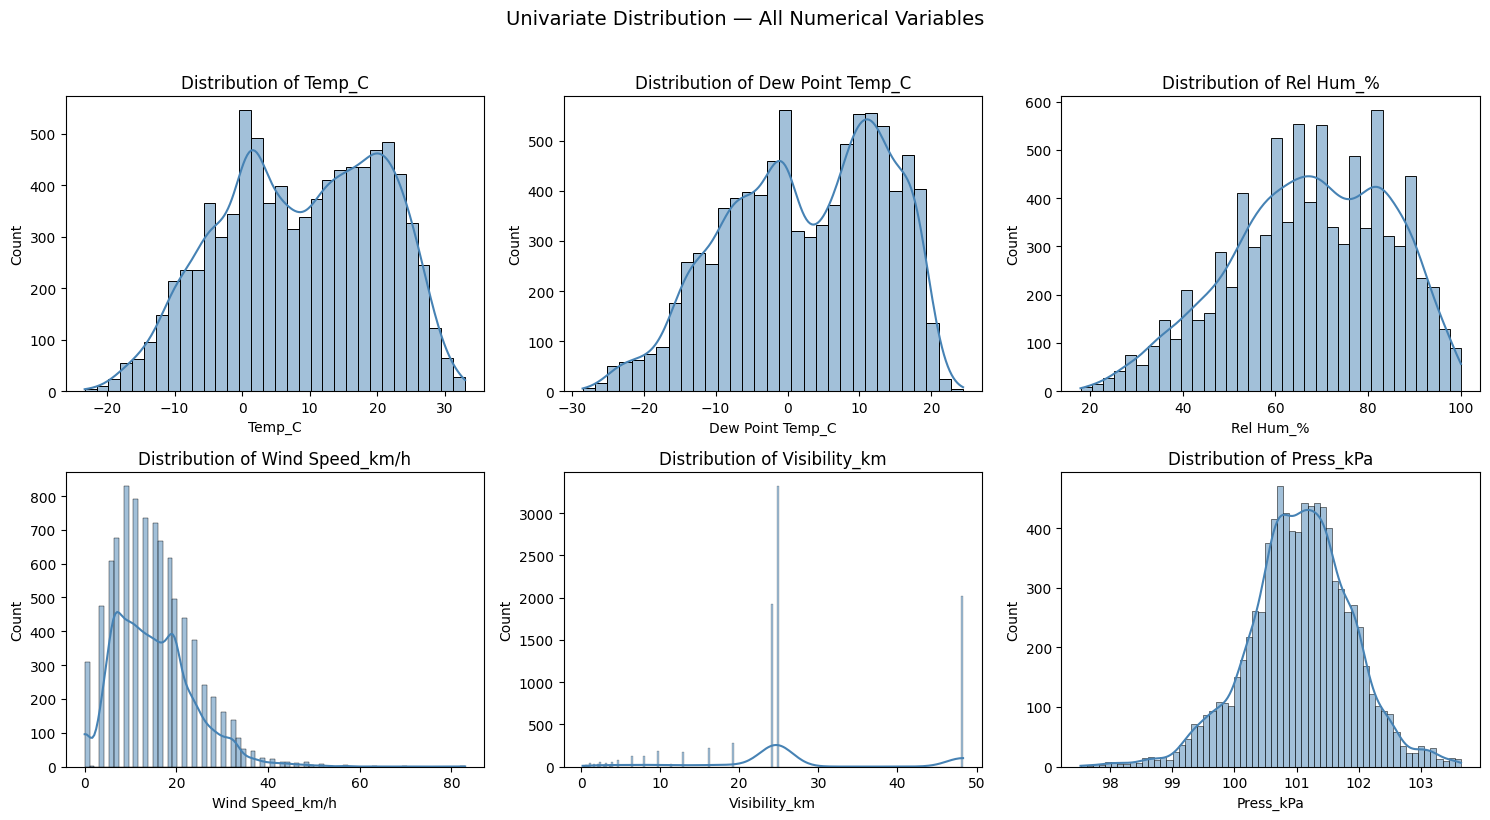

In [89]:
# Numerical columns we'll analyze
num_cols = ['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa']

# Histogram + KDE for each numerical column — shows distribution shape
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle("Univariate Distribution — All Numerical Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [90]:
# Skewness of each numerical column
# Positive = right-skewed, Negative = left-skewed, ~0 = roughly normal
print("Skewness per column:")
print(data[num_cols].skew().round(3))

Skewness per column:
Temp_C             -0.178
Dew Point Temp_C   -0.318
Rel Hum_%          -0.324
Wind Speed_km/h     0.871
Visibility_km       0.413
Press_kPa          -0.230
dtype: float64


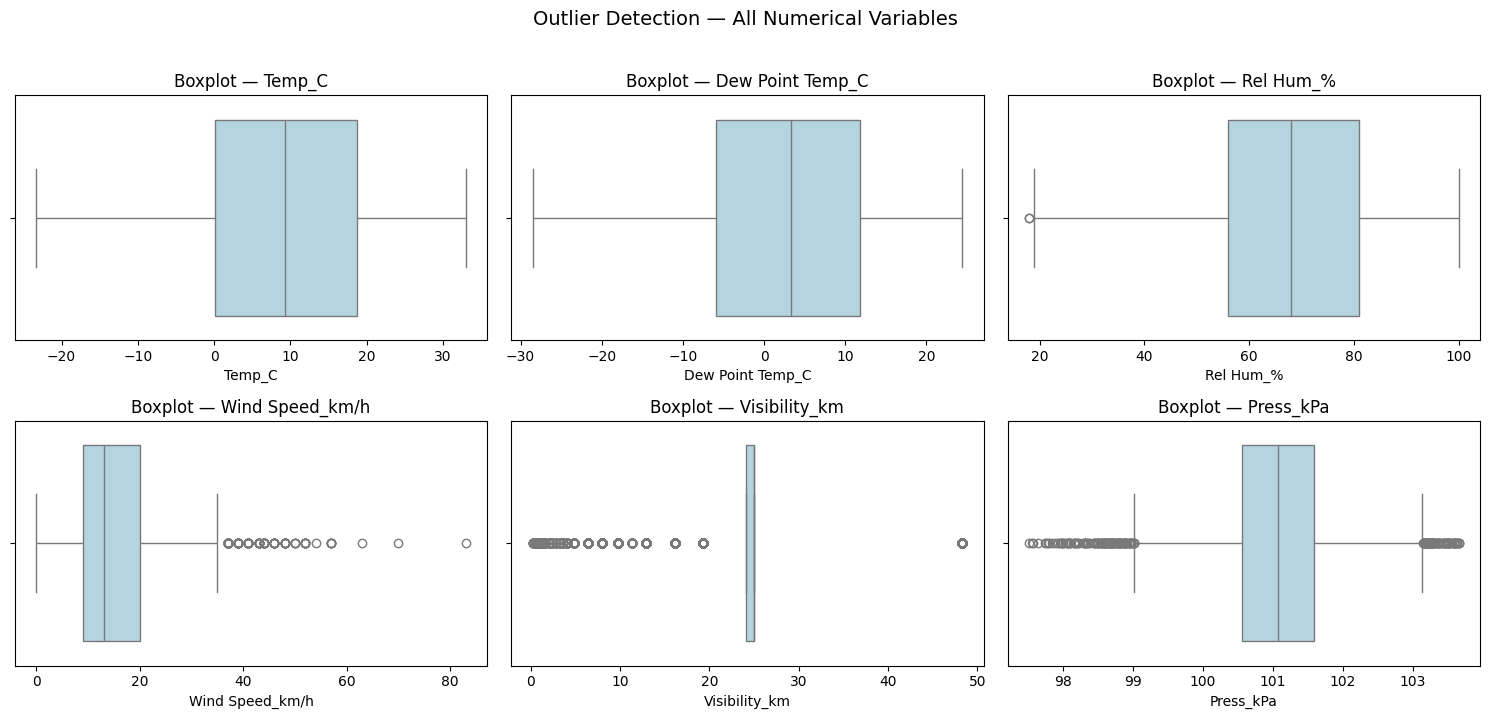

In [91]:
# Boxplot for all numerical columns — quick outlier detection across all variables
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=data[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot — {col}')

plt.suptitle("Outlier Detection — All Numerical Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 9.2 Univariate — Categorical Variables

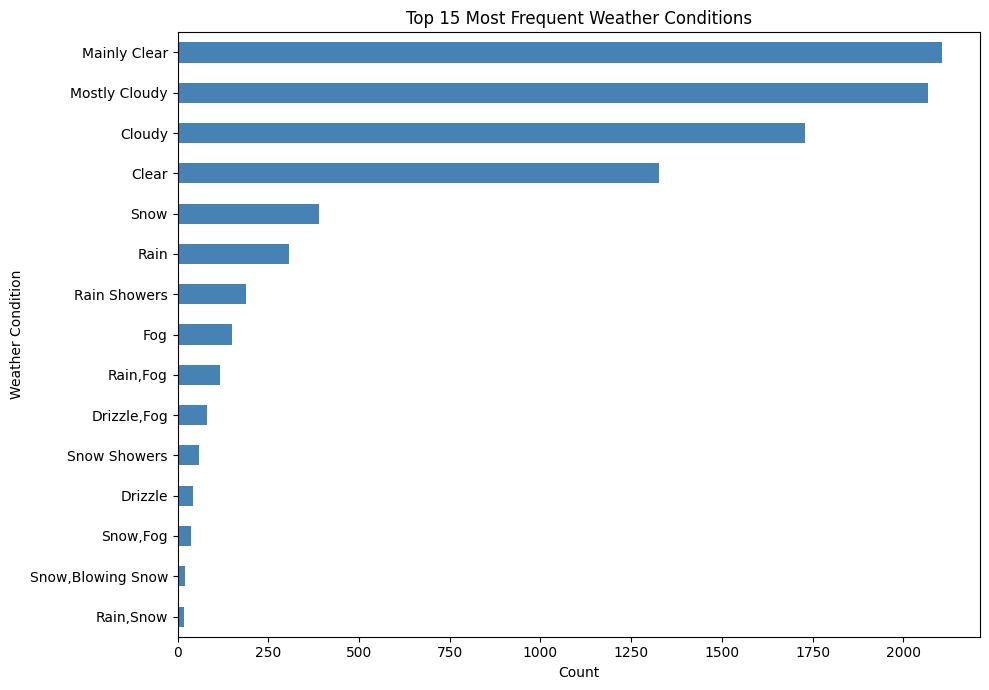

In [92]:
# Top 15 most frequent weather conditions — horizontal bar for readability
top15 = data['Weather_Condition'].value_counts().head(15)

plt.figure(figsize=(10, 7))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 15 Most Frequent Weather Conditions")
plt.xlabel("Count")
plt.ylabel("Weather Condition")
plt.tight_layout()
plt.show()

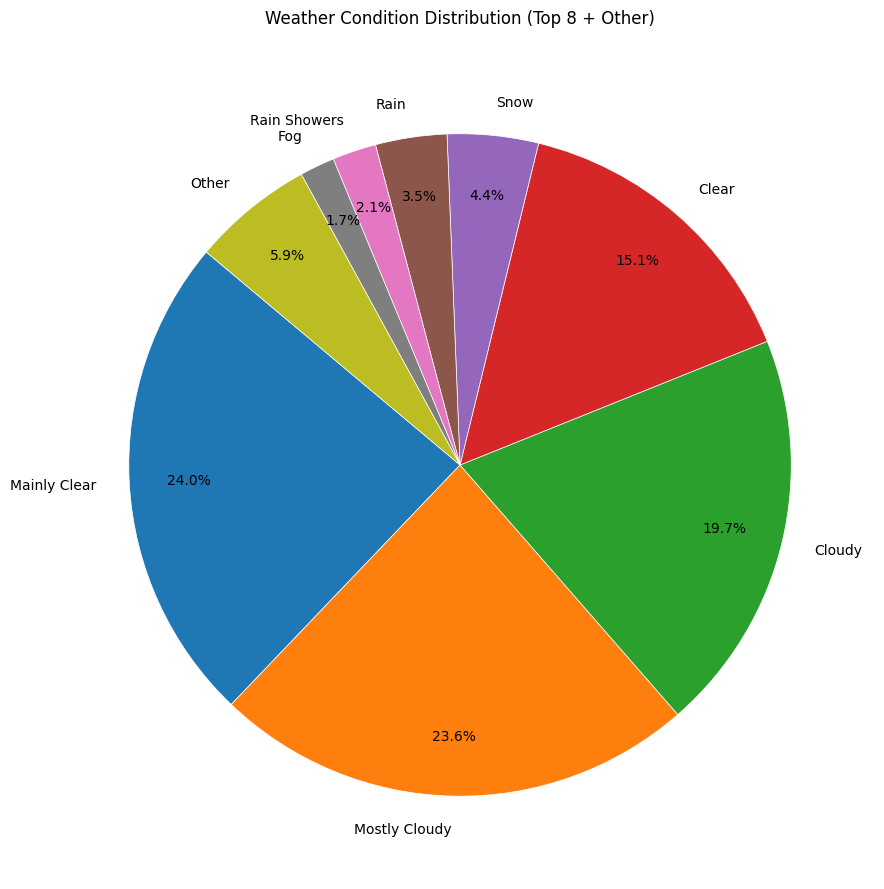

In [93]:
# Pie chart — Top 8 conditions + 'Other' group
# Grouping avoids label overlap from 50 unique conditions
top8 = data['Weather_Condition'].value_counts().head(8)
other = data['Weather_Condition'].value_counts().iloc[8:].sum()
pie_data = pd.concat([top8, pd.Series({'Other': other})])

plt.figure(figsize=(9, 9))
plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(linewidth=0.5, edgecolor='white')
)
plt.title("Weather Condition Distribution (Top 8 + Other)", pad=20)
plt.tight_layout()
plt.show()

### 9.3 Bivariate — Numerical vs Numerical

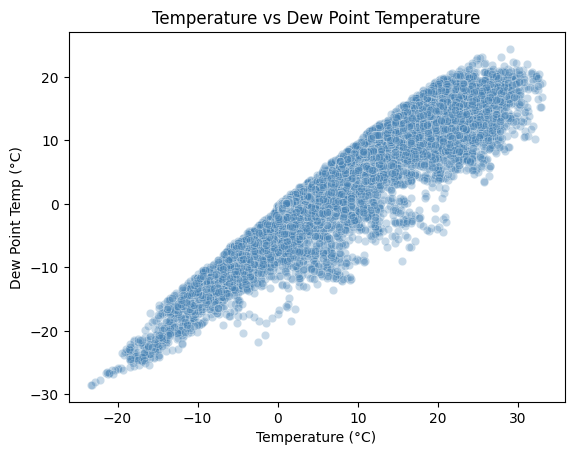

In [94]:
# Scatter: Temperature vs Dew Point — strong positive relationship expected
sns.scatterplot(x='Temp_C', y='Dew Point Temp_C', data=data, alpha=0.3, color='steelblue')
plt.title("Temperature vs Dew Point Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Dew Point Temp (°C)")
plt.show()

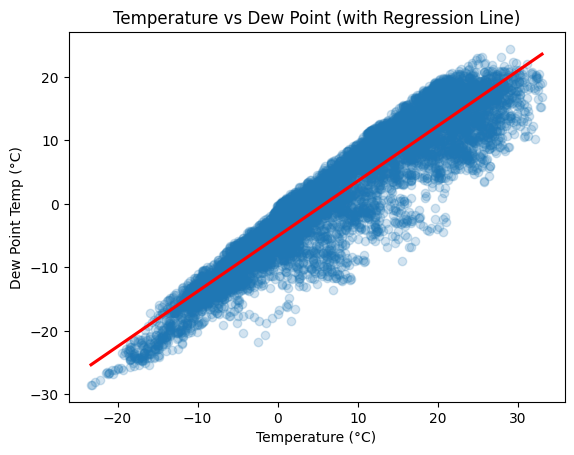

In [95]:
# Regplot: adds regression line to quantify the relationship strength
sns.regplot(x='Temp_C', y='Dew Point Temp_C', data=data,
            scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
plt.title("Temperature vs Dew Point (with Regression Line)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Dew Point Temp (°C)")
plt.show()

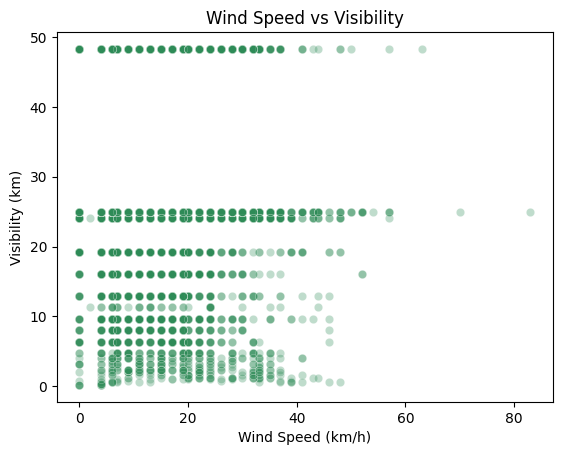

In [96]:
# Scatter: Wind Speed vs Visibility — does higher wind improve visibility?
sns.scatterplot(x='Wind Speed_km/h', y='Visibility_km', data=data, alpha=0.3, color='seagreen')
plt.title("Wind Speed vs Visibility")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Visibility (km)")
plt.show()

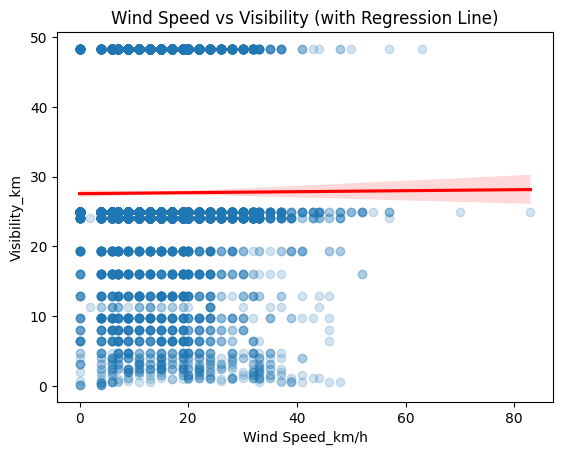

In [97]:
# Regplot: Wind Speed vs Visibility
sns.regplot(x='Wind Speed_km/h', y='Visibility_km', data=data,
            scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
plt.title("Wind Speed vs Visibility (with Regression Line)")
plt.show()

### 9.4 Bivariate — Numerical vs Categorical

In [98]:
# Focus on top 6 conditions only — full 50 makes plots unreadable
top6 = data['Weather_Condition'].value_counts().head(6).index
data_top6 = data[data['Weather_Condition'].isin(top6)]

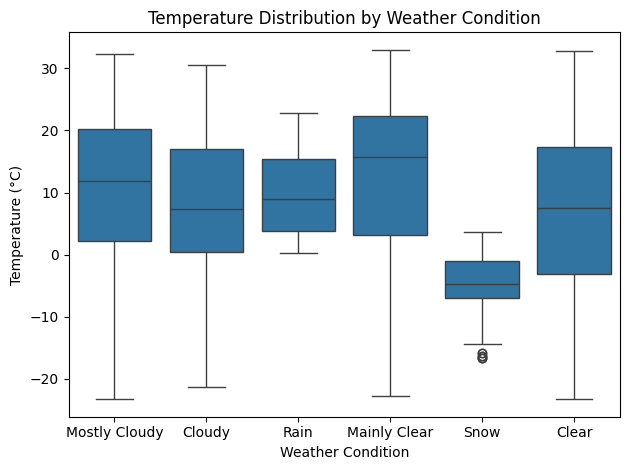

In [99]:
# Boxplot: Temperature distribution per weather condition
sns.boxplot(x='Weather_Condition', y='Temp_C', data=data_top6)
plt.title("Temperature Distribution by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

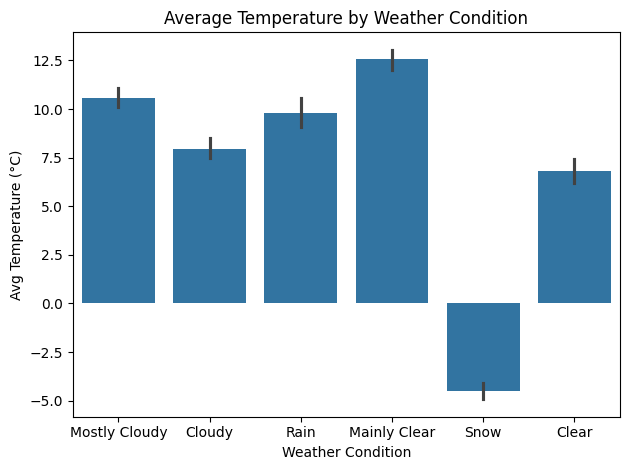

In [100]:
# Barplot: Average temperature per weather condition
sns.barplot(x='Weather_Condition', y='Temp_C', data=data_top6)
plt.title("Average Temperature by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Avg Temperature (°C)")
plt.tight_layout()
plt.show()

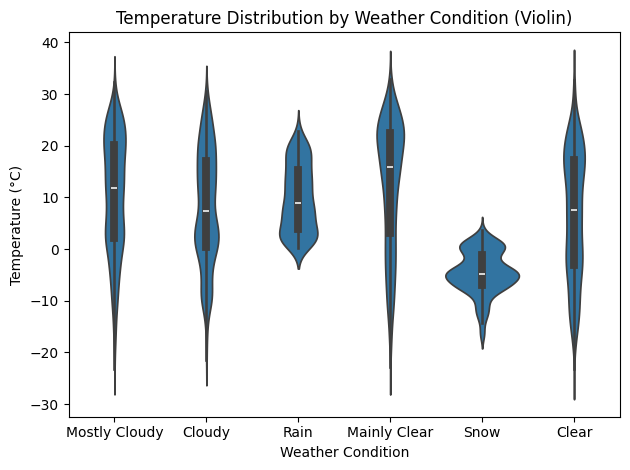

In [101]:
# Violin plot: shows both distribution shape and summary stats simultaneously
sns.violinplot(x='Weather_Condition', y='Temp_C', data=data_top6)
plt.title("Temperature Distribution by Weather Condition (Violin)")
plt.xlabel("Weather Condition")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

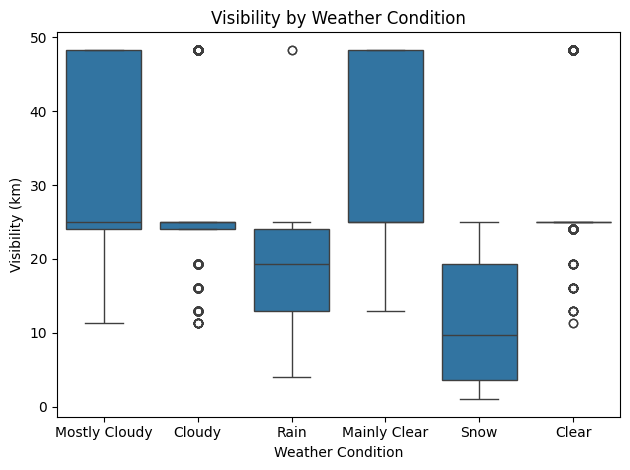

In [102]:
# Boxplot: Visibility per weather condition — foggy/snowy = low visibility?
sns.boxplot(x='Weather_Condition', y='Visibility_km', data=data_top6)
plt.title("Visibility by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Visibility (km)")
plt.tight_layout()
plt.show()

### 9.5 Bivariate — Categorical vs Categorical

In [103]:
# Create a season column from the month — allows cat vs cat comparison
data['Month'] = pd.to_datetime(data['Date/Time']).dt.month

def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else:                    return 'Fall'

data['Season'] = data['Month'].apply(get_season)
print(data['Season'].value_counts())

Season
Spring    2208
Summer    2208
Winter    2184
Fall      2184
Name: count, dtype: int64


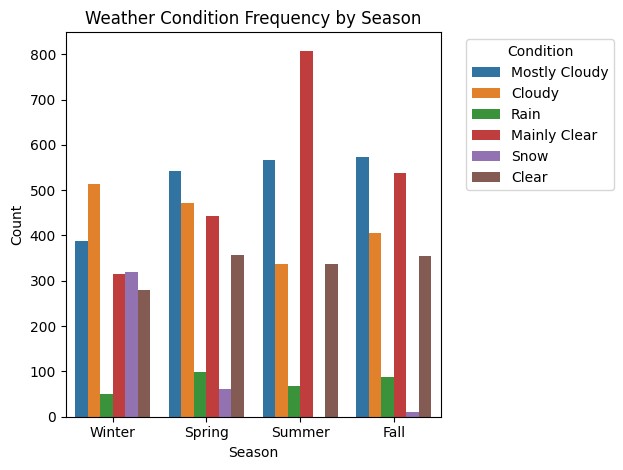

In [104]:
# Countplot: how do top 6 weather conditions distribute across seasons?
sns.countplot(x='Season', hue='Weather_Condition',
              data=data[data['Weather_Condition'].isin(top6)],
              order=['Winter', 'Spring', 'Summer', 'Fall'])
plt.title("Weather Condition Frequency by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 9.6 Multivariate Analysis

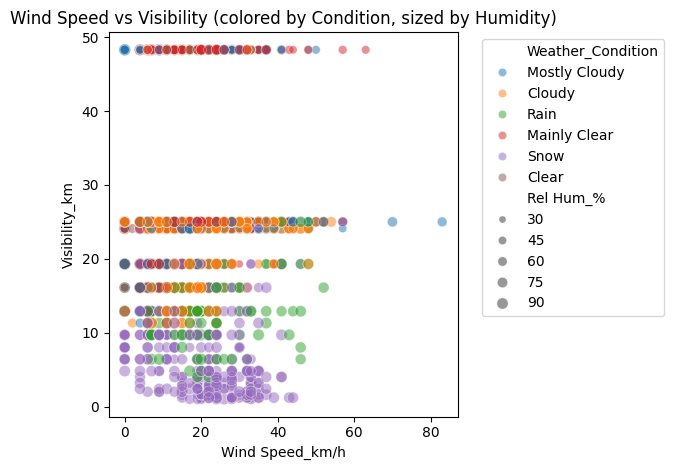

In [105]:
# Scatter with hue + size — 4 dimensions at once:
# x=Wind Speed, y=Visibility, hue=Weather Condition, size=Humidity
sns.scatterplot(
    x='Wind Speed_km/h',
    y='Visibility_km',
    hue='Weather_Condition',
    size='Rel Hum_%',
    data=data_top6,
    alpha=0.5
)
plt.title("Wind Speed vs Visibility (colored by Condition, sized by Humidity)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

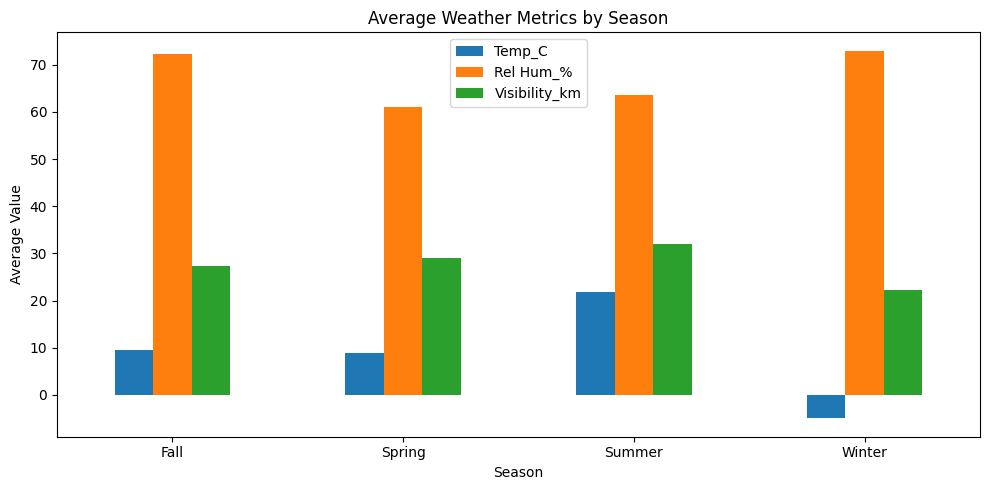

In [106]:
# Average Temperature, Humidity, and Visibility per season
season_means = data.groupby('Season')[['Temp_C', 'Rel Hum_%', 'Visibility_km']].mean()

season_means.plot(kind='bar', figsize=(10, 5), rot=0)
plt.title("Average Weather Metrics by Season")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.tight_layout()
plt.show()

### 9.7 Correlation Heatmap

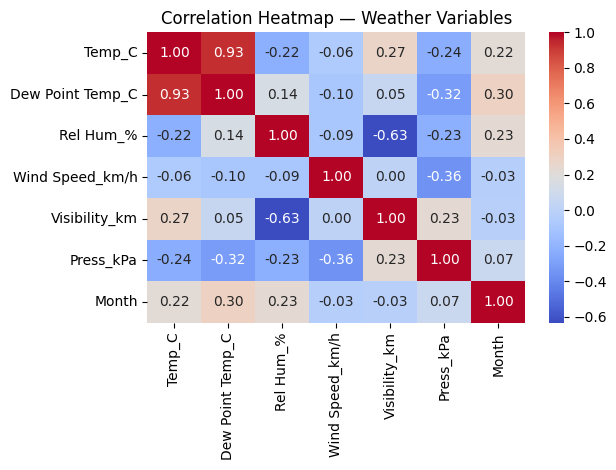

In [107]:
# Heatmap of correlations between all numerical variables
# Values close to 1 or -1 = strong relationship; close to 0 = weak/none
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap — Weather Variables")
plt.tight_layout()
plt.show()

### 9.8 Pairplot — All Numerical Variables

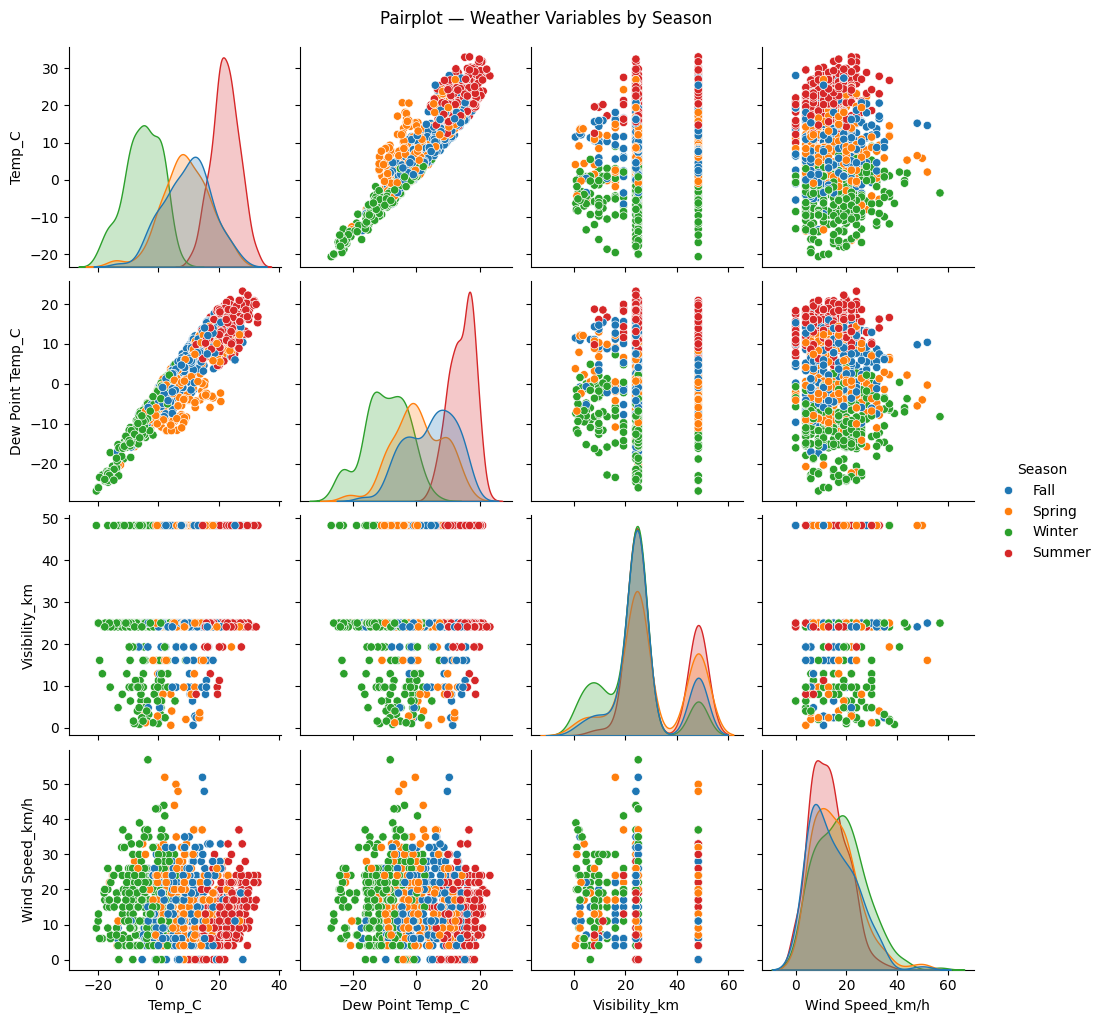

In [108]:
# Pairplot colored by Season — shows all pairwise relationships at once
# Using a sample of 1000 rows to avoid slow rendering
sns.pairplot(
    data[['Temp_C', 'Dew Point Temp_C', 'Visibility_km', 'Wind Speed_km/h', 'Season']].sample(1000, random_state=42),
    hue='Season'
)
plt.suptitle("Pairplot — Weather Variables by Season", y=1.02)
plt.show()

## 10. Key Insights

After analyzing **8,784 hourly weather records** from Canada (2012):

1. **Temperature and Dew Point are strongly correlated**  
   The scatter and regression plots show a near-linear relationship — as temperature rises, dew point follows closely, confirming their physical dependence.

2. **Fog and Snow produce the lowest visibility**  
   The boxplot of Visibility by Weather Condition clearly shows Fog and Snow pushing visibility to the lowest ranges, while Clear and Mainly Clear conditions reach the highest values.

3. **Winter dominates the dataset with extreme conditions**  
   The Season analysis reveals that Snow, Fog, and Rain cluster heavily in Winter months, while Summer is dominated by Mainly Clear and Mostly Cloudy conditions.

4. **Wind speed has minimal effect on visibility**  
   Despite the expectation that wind disperses fog, the scatter and regression plot show almost no correlation between wind speed and visibility in this dataset.

5. **Pressure is the most stable variable**  
   Among all numerical columns, `Press_kPa` has the lowest skewness and smallest relative standard deviation — barometric pressure changes very slowly hour-to-hour.

6. **Humidity is highest in foggy and rainy conditions**  
   The multivariate scatter (sized by humidity) shows that high-humidity points cluster around low-visibility, low-wind conditions — aligning with real-world meteorology.
